<a href="https://colab.research.google.com/github/billyprodev/ai-micro-credit-scoring-unbanked/blob/main/RARM_competition_Team7_ai_micro_credit_scoring_unbanked.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Challenge d’innovation autour des solutions numériques et de l’intelligence artificielle appliquées au Risk Management

https://rimrae.com/rarmchallenge2026/

Termes de Référence

https://drive.google.com/file/d/1K113rskLNHp_Ui0yvCaY-hEkVuWwXUap/view


Thème 5 – Risques financiers dans le secteur informel et inclusion
Intitulé :
Micro-scoring et détection de surendettement pour les TPE non bancarisées.
Problème :
Les commerçants, agriculteurs et artisans n'ont pas de score de crédit classique, mais
s'endettent via tontines, micro-crédits ou mobile money.
Solution IA :

• Modèle alternatif de risque de crédit (données de remboursement informel, flux M-
Pesa/Orange Money, récurrence des achats).

• Signalement de surendettement croisé entre différentes institutions de microfinance.
• Recommandation de produits d'épargne pour lisser les risques saisonniers.

In [ ]:
pip install streamlit pandas scikit-learn

In [ ]:
import pandas as pd
#data = pd.read_csv("microcredit_dataset.csv")
data = pd.read_csv("https://raw.githubusercontent.com/billyprodev/ai-micro-credit-scoring-unbanked/refs/heads/main/microcredit_dataset.csv")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = data.drop("default_risk", axis=1)
X = pd.get_dummies(X)  # pour activity

y = data["default_risk"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a RandomForest model
model = RandomForestClassifier()

# Train the model on the training data
#model.fit(X, y)
model.fit(X_train, y_train)

RandomForestClassifier()

ROC AUC: 1.00
PR AUC: 1.00
Gini: 1.00
KS: 1.00


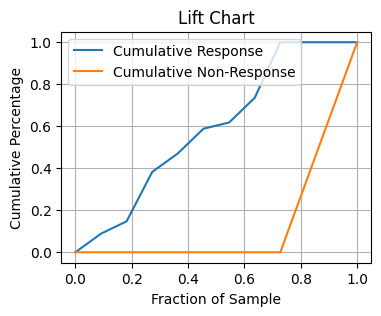

Accuracy: 1.00

Confusion Matrix:
[[ 6  0]
 [ 0 34]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        34

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc as pr_auc

# Predict probabilities for the test data
y_prob = model.predict_proba(X_test)[:, 1]
# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

#y_pred = model.predict(X)

# Calculate precision-recall curve and AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc_score = pr_auc(recall, precision)

# Calculate Gini coefficient
gini = 2 * roc_auc - 1

# Calculate KS statistic
ks = max(tpr - fpr)

# Print the results
print(f"ROC AUC: {roc_auc:.2f}")
print(f"PR AUC: {pr_auc_score:.2f}")
print(f"Gini: {gini:.2f}")
print(f"KS: {ks:.2f}")

# Create a lift chart
plt.figure(figsize=(4, 3))
plt.plot(np.linspace(0, 1, len(tpr)), tpr, label='Cumulative Response')
plt.plot(np.linspace(0, 1, len(fpr)), fpr, label='Cumulative Non-Response')
plt.xlabel('Fraction of Sample')
plt.ylabel('Cumulative Percentage')
plt.title('Lift Chart')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the model
y_pred = (y_prob > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the evaluation results
print(f"Accuracy: {accuracy:.2f}")
print("")
print("Confusion Matrix:")
print(confusion)
print("")
print("Classification Report:")
print(classification_rep)

In [ ]:
def predict(user_input):
    user_df = pd.DataFrame([user_input])
    user_df = pd.get_dummies(user_df)
    user_df = user_df.reindex(columns=X.columns, fill_value=0)

    prob = model.predict_proba(user_df)[0][1]
    score = int((1 - prob) * 100)

    return score


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# LOAD DATA
# -----------------------------
#data = pd.read_csv("microcredit_dataset.csv")
data = pd.read_csv("https://raw.githubusercontent.com/billyprodev/ai-micro-credit-scoring-unbanked/refs/heads/main/microcredit_dataset.csv")

X = data.drop("default_risk", axis=1)
X = pd.get_dummies(X)

y = data["default_risk"]

model = RandomForestClassifier()
model.fit(X, y)

# -----------------------------
# APP UI
# -----------------------------
st.set_page_config(page_title="AI Micro-Credit Scoring", layout="wide")

st.title("💳 AI Micro-Credit Risk Engine")
st.write("Scoring de crédit basé sur Mobile Money & Tontines")

# -----------------------------
# INPUT USER
# -----------------------------
st.sidebar.header("📋 Profil Client")

age = st.sidebar.slider("Âge", 18, 65, 30)
activity = st.sidebar.selectbox("Activité", ["commerce", "agriculture", "artisan", "service"])
years_activity = st.sidebar.slider("Années d'activité", 1, 20, 3)

monthly_income = st.sidebar.number_input("Revenu mensuel (FCFA)", 30000, 1000000, 150000)
transaction_freq = st.sidebar.slider("Transactions mensuelles", 5, 200, 50)
income_volatility = st.sidebar.slider("Volatilité revenus", 0.0, 1.0, 0.3)

tontine_contribution = st.sidebar.number_input("Contribution tontine", 5000, 100000, 20000)
tontine_regularity = st.sidebar.slider("Régularité tontine", 0.5, 1.0, 0.8)

expenses_ratio = st.sidebar.slider("Dépenses / Revenus", 0.3, 1.5, 0.8)
existing_debt = st.sidebar.number_input("Dette existante (FCFA)", 0, 500000, 50000)

# -----------------------------
# PREDICTION
# -----------------------------
def predict():
    user_input = {
        "age": age,
        "activity": activity,
        "years_activity": years_activity,
        "monthly_income": monthly_income,
        "transaction_freq": transaction_freq,
        "income_volatility": income_volatility,
        "tontine_contribution": tontine_contribution,
        "tontine_regularity": tontine_regularity,
        "expenses_ratio": expenses_ratio,
        "existing_debt": existing_debt
    }

    df = pd.DataFrame([user_input])
    df = pd.get_dummies(df)
    df = df.reindex(columns=X.columns, fill_value=0)

    prob = model.predict_proba(df)[0][1]
    score = int((1 - prob) * 100)

    return score, prob

# -----------------------------
# DISPLAY RESULTS
# -----------------------------
if st.button("🚀 Analyser le client"):
    score, risk = predict()

    st.subheader("📊 Résultat du scoring")

    col1, col2, col3 = st.columns(3)

    col1.metric("Score Crédit", f"{score}/100")

    if score > 70:
        col2.success("✅ Faible risque")
    elif score > 40:
        col2.warning("⚠️ Risque modéré")
    else:
        col2.error("🔴 Risque élevé")

    col3.metric("Probabilité de défaut", f"{int(risk*100)}%")

    # -----------------------------
    # ALERTS
    # -----------------------------
    st.subheader("🚨 Alertes")

    if expenses_ratio > 1:
        st.error("Surconsommation détectée")

    if existing_debt > 200000:
        st.error("Risque de surendettement")

    if tontine_regularity < 0.7:
        st.warning("Faible discipline tontine")

    # -----------------------------
    # RECOMMENDATIONS
    # -----------------------------
    st.subheader("💡 Recommandation crédit")

    if score > 70:
        st.success("✅ Crédit recommandé : 150 000 FCFA")
        st.write("Durée : 6 mois | Faible risque")
    elif score > 40:
        st.warning("⚠️ Crédit limité : 75 000 FCFA")
        st.write("Durée : 3 mois | Surveillance requise")
    else:
        st.error("❌ Crédit non recommandé")
        st.write("Proposer épargne ou formation financière")

Overwriting app.py


First, install `ngrok` and import the necessary libraries.

In [ ]:
# Install ngrok
!pip install pyngrok

In [ ]:
from pyngrok import ngrok
from google.colab import userdata

# Terminate any previous ngrok tunnels
ngrok.kill()

# Get ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Authenticate ngrok
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open a tunnel to port 8501 (Streamlit's default port)
tunnel = ngrok.connect(8501)
print(f"Streamlit App URL: {tunnel.public_url}")

Streamlit App URL: https://village-spiral-landowner.ngrok-free.dev


Now, you can run your Streamlit application in a separate cell. After executing the cell above, you will see a public URL. Click on that URL to access your Streamlit app. Make sure to interrupt this cell's execution when you are done with the Streamlit app.

In [ ]:
!streamlit run app.py



2026-07-01 11:09:27.161 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.136.216.198:8501



  Stopping...
